In [1]:
import numpy as np
import pandas as pd
import stan
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('/mrhome/amingk/Documents/7TPD/ActStimRL')
from utils import model_utils, config
import os

In [2]:
# Main directory of the subject
readMainDirec = '/mnt/projects/7TPD/bids/derivatives/fMRI_DA/AllBehData/'
# read clinical evaluation
clinical_evaluation = pd.read_csv(config.SCARTCH_CLIN_EVAL_FILE)
 

In [3]:
# PD clinical evaluation
clinical_evaluation_PD = clinical_evaluation[clinical_evaluation['group']=='PD']
clinical_evaluation_PD= clinical_evaluation_PD[~clinical_evaluation_PD['sub_ID'].isin(['sub-025', 'sub-052', 'sub-010'])]
most_affected = (clinical_evaluation_PD['most_affected_left_right_side_UPDRSON'] - clinical_evaluation_PD['most_affected_left_right_side_UPDRSOFF']).to_numpy()
UPDRS = (clinical_evaluation_PD['total_UPDRSON'] - clinical_evaluation_PD['total_UPDRSOFF']).to_numpy()

In [4]:
map_med_weighting = clinical_evaluation_PD['map_med_weighting']
map_mean_weighting_act = clinical_evaluation_PD['map_mean_weighting_act']

In [5]:
clinical_evaluation_PD.columns

Index(['sub_ID', 'x_number', 'group', 'age', 'sex', 'disease_duration',
       'time_symptomns', 'most_affected_left_right_side_baselineUPDRS',
       'most_affected_left_right_side_UPDRSOFF',
       'most_affected_left_right_side_UPDRSON',
       'systolic_blood_pressure_baselineUPDRS', 'total_BaselineUPDRS',
       'total_UPDRSOFF', 'total_UPDRSON', 'NMSS', 'MoCA', 'BDI', 'LARS',
       'map_mean_alpha_pos', 'map_mean_alpha_neg', 'map_mean_sensitivity',
       'map_mean_weighting_act', 'map_mean_weighting_clr',
       'map_mean_weighting', 'map_med_alpha_pos', 'map_med_alpha_neg',
       'map_med_sensitivity', 'map_med_weighting_act', 'map_med_weighting_clr',
       'map_med_weighting', 'med_UPDRS'],
      dtype='object')

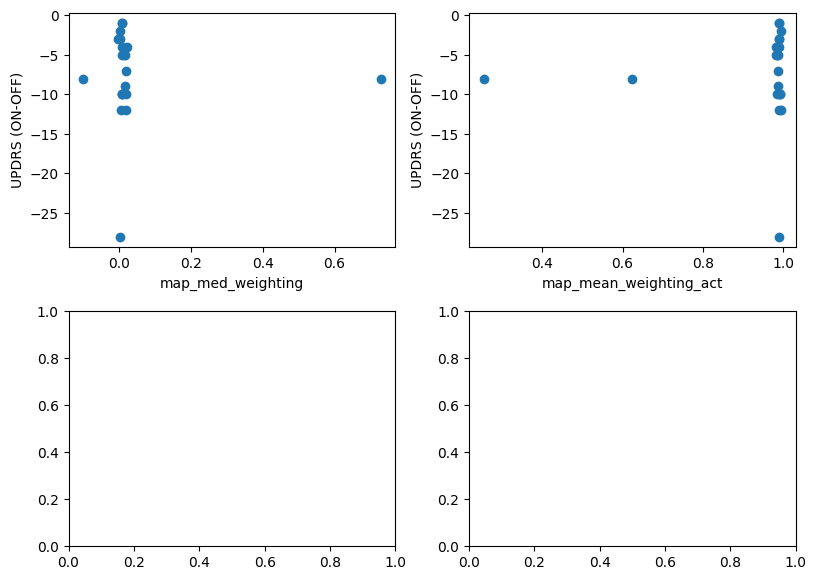

In [6]:
# ---------- Setup Figure----------
# Desired size in cm
width_cm = 21
height_cm = 15
# Convert to inches
width_in = width_cm / 2.54
height_in = height_cm / 2.54


fig, axs = plt.subplots(2, 2, figsize=(width_in, height_in))
axs = axs.flatten()

# poistive learning rate
axs[0].scatter(map_med_weighting, UPDRS)
axs[0].set_xlabel('map_med_weighting')
axs[0].set_ylabel('UPDRS (ON-OFF)')

# negative learning rate
axs[1].scatter(map_mean_weighting_act, UPDRS)
axs[1].set_xlabel('map_mean_weighting_act')
axs[1].set_ylabel('UPDRS (ON-OFF)')

# Layout
plt.tight_layout()

In [7]:
np.mean([map_weighting_PD[:,0, 1],map_weighting_PD[:,0, 0], 1- map_weighting_PD[:,1, 1], 1-map_weighting_PD[:,1, 0]])

NameError: name 'map_weighting_PD' is not defined

In [ ]:
map_weighting_PD

array([ 3.66383089e-03, -5.24365912e-03,  1.65818107e-01,  1.27316334e-02,
       -5.73926381e-01,  7.01638974e-01,  1.17244329e-01, -2.76667900e-04,
       -5.93395931e-03, -3.58713138e-01, -1.45458785e-02,  4.16098503e-01,
       -1.89105321e-01,  2.38552197e-01, -2.28570602e-01,  3.58000179e-03,
        1.32479363e-02,  9.23509968e-03, -1.12980130e-02, -2.31930280e-01,
        1.53392247e-03,  3.86938428e-03, -2.66227256e-05])

In [ ]:
map_med_alpha_neg_PD

array([ 0.10615491,  0.14308827, -0.11388362,  0.02435404,  0.1389073 ,
        0.00109458,  0.12459165,  0.16136731,  0.02690609,  0.02472865,
       -0.00367531, -0.05082702,  0.00542235,  0.05350417, -0.14960387,
        0.49030679,  0.08542884,  0.11380636,  0.02594226,  0.42246764,
        0.33535871, -0.23232243,  0.07255947])